In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_train.csv
/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_test.csv


# 1.Titanicデータ分析

## 概要
KaggleのTitanicデータを用いて、生存率に影響する要因を分析

## 使用技術
- Python
- pandas
- seaborn

## 分析内容
・性別と生存率の関係  
・年齢と生存率の関係  
・同伴者（SibSp）と生存率の関係

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


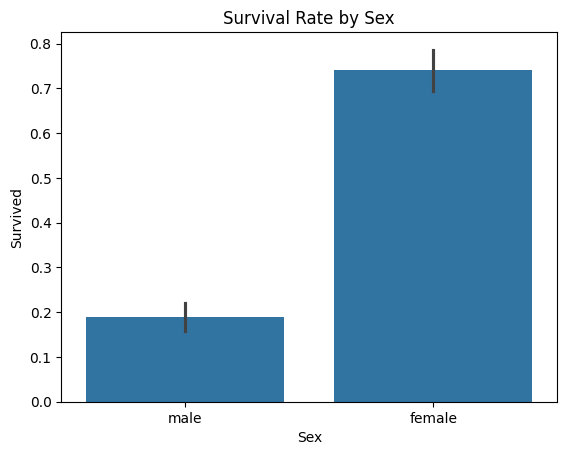

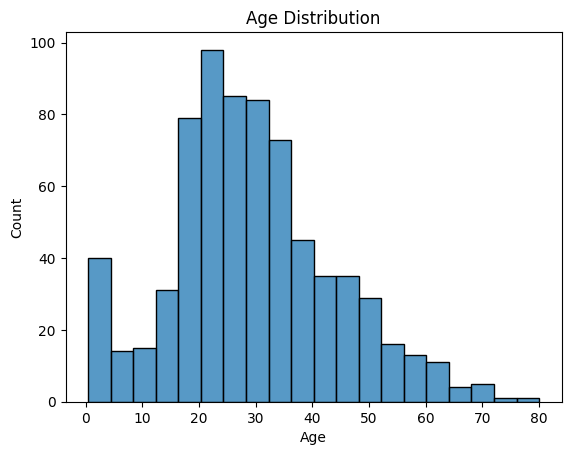

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# データ読み込み（KaggleではこれでOK）
df = pd.read_csv('/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_train.csv')

# 最初の確認
print(df.head())

# 性別ごとの生存率
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# 年齢分布
sns.histplot(df['Age'].dropna(), bins=20)
plt.title('Age Distribution')
plt.show()

男性と女性では女性のほうが生存している
年齢と人数の関係から20~40代までが母数が多い
また、乳児の人数もある程度多いことがわかる

次に、年代ごとの生死と任数の関係について分析

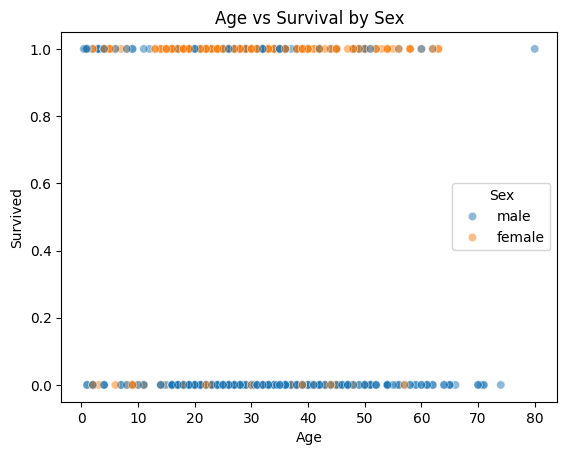

In [3]:
#年齢と生存の関係

# 欠損値除去（重要）
df = df.dropna(subset=['Age'])

# 性別ごとにプロット
sns.scatterplot(data=df, x='Age', y='Survived', hue='Sex', alpha=0.5)

plt.title('Age vs Survival by Sex')
plt.show()

20から60歳付近で広く男性の生存率が低い

性別ごとの生死と人数の関係について可視化してみる
(グラフは密集して見ずらい)

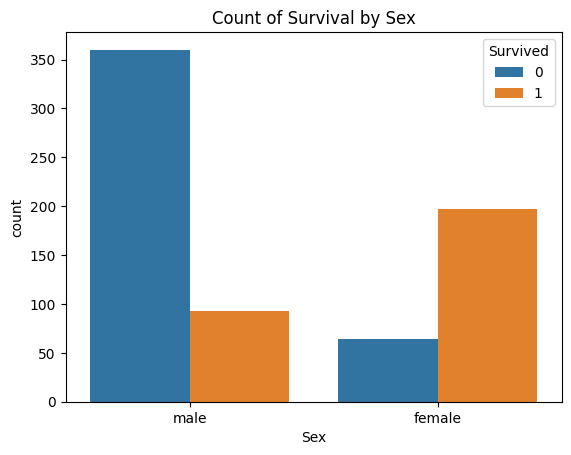

In [4]:
#性別ごとの生存（人数）

# 人数をカウントして表示
sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Count of Survival by Sex')
plt.show()

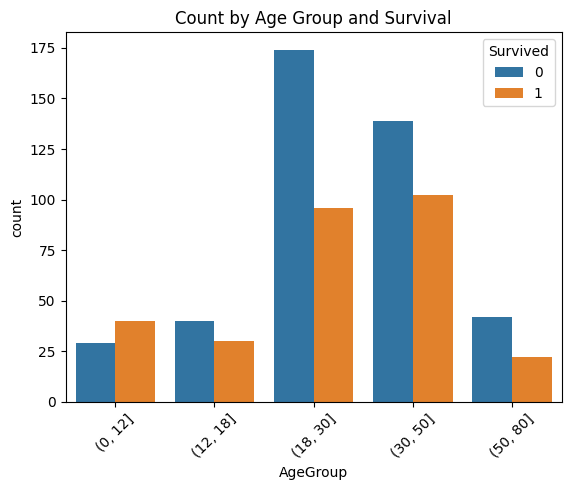

In [5]:
# 年齢をグループ化
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 80])

sns.countplot(data=df, x='AgeGroup', hue='Survived')
plt.xticks(rotation=45)
plt.title('Count by Age Group and Survival')
plt.show()

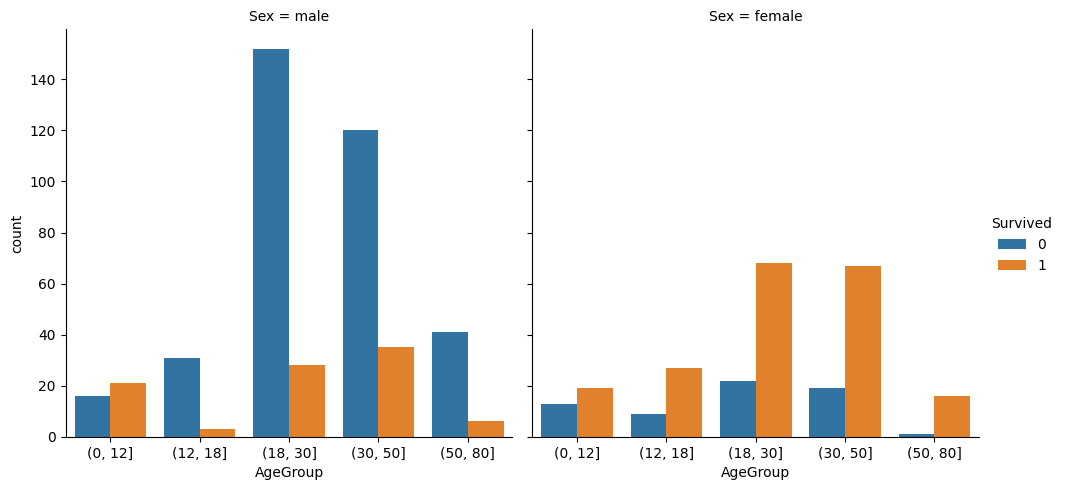

In [6]:
sns.catplot(data=df, x='AgeGroup', hue='Survived', col='Sex', kind='count')

In [7]:
df['HasSpouse'] = df['SibSp'] > 0

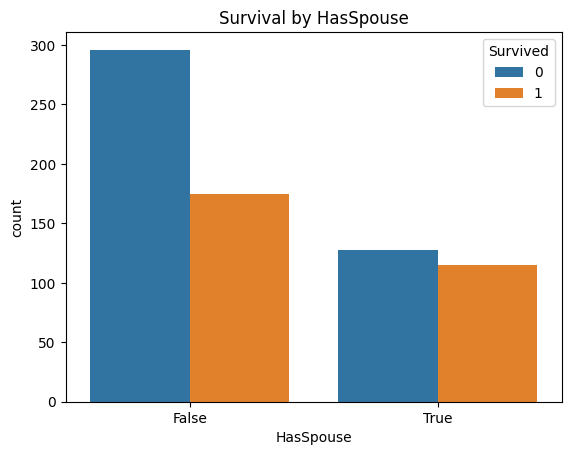

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='HasSpouse', hue='Survived')
plt.title('Survival by HasSpouse')
plt.show()

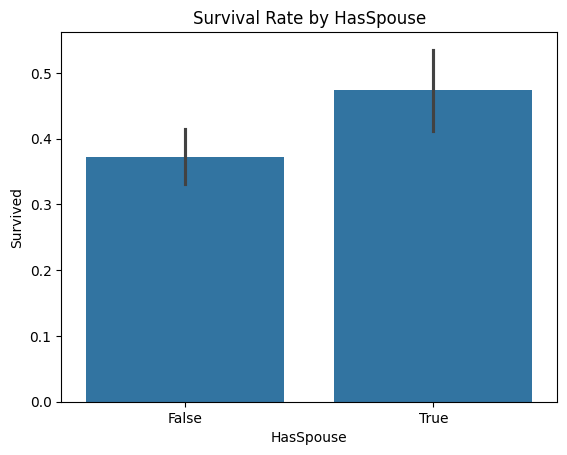

In [9]:
sns.barplot(data=df, x='HasSpouse', y='Survived')
plt.title('Survival Rate by HasSpouse')
plt.show()

<Axes: xlabel='HasSpouse', ylabel='Survived'>

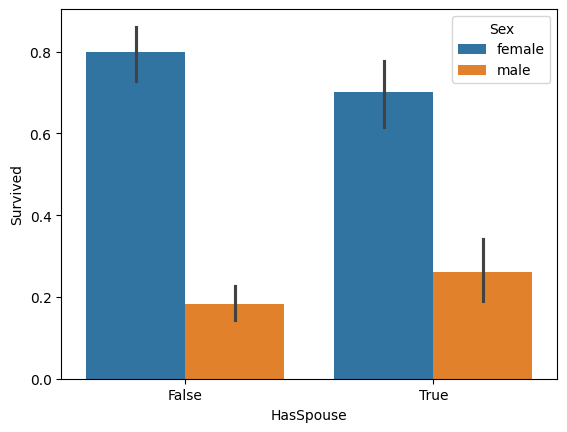

In [10]:
sns.barplot(data=df, x='HasSpouse', y='Survived', hue='Sex')

  ## 結果
・女性の方が生存率が高い  
・単独よりも同伴者ありの方が生存率が異なる傾向  
・家族構成が生存率に影響している可能性  



# 2. Titanic分析（続き）
# ① 前回の内容
- Titanicデータから生存に関する特徴として男女で差があることが分かった
- さらに、その内訳について分析した結果、家族構成が生存に影響している可能性が浮上した


# ②各生存率とグラフの作成
# 性別ごとの生存率

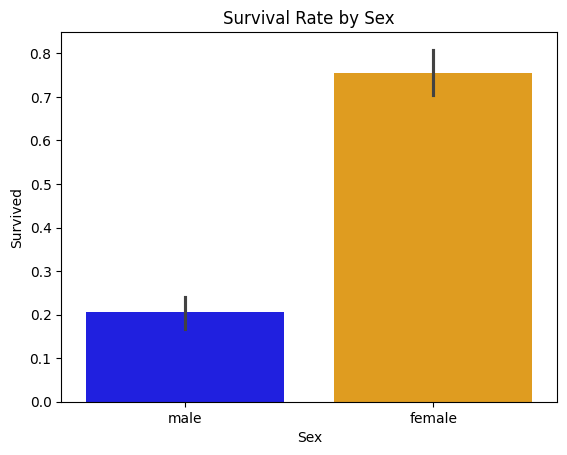

Sex
female    0.754789
male      0.205298
Name: Survived, dtype: float64

In [11]:
# 性別ごとの生存率
sns.barplot(x='Sex', y='Survived',hue ='Sex', data=df,palette={'female':'orange','male':'blue'})
plt.title('Survival Rate by Sex')
plt.show()

df.groupby('Sex')['Survived'].mean()

女性：74.2%, 男性：18.9%

- 女性が生存率高い

- すべての条件でそうなのか？（家族構成など？）

# 家族構成によるの生存率

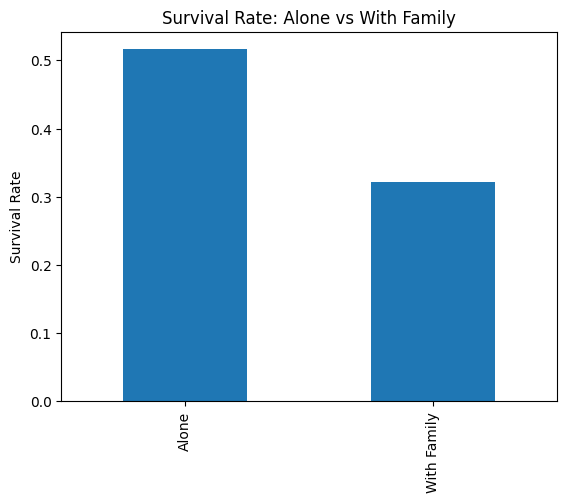

IsAlone
0    0.516129
1    0.321782
Name: Survived, dtype: float64

In [12]:
df['IsAlone'] = (df['SibSp'] + df['Parch'] == 0).astype(int)

survival_rate = df.groupby('IsAlone')['Survived'].mean()

survival_rate.index = ['Alone', 'With Family']

survival_rate.plot(kind='bar')
plt.title('Survival Rate: Alone vs With Family')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('IsAlone')['Survived'].mean()

一人：50.5%, それ以外：30.3%

- 一人のほうが高い
- 男性の死亡率が影響している？

# 性別および家族構成を考慮した生存率

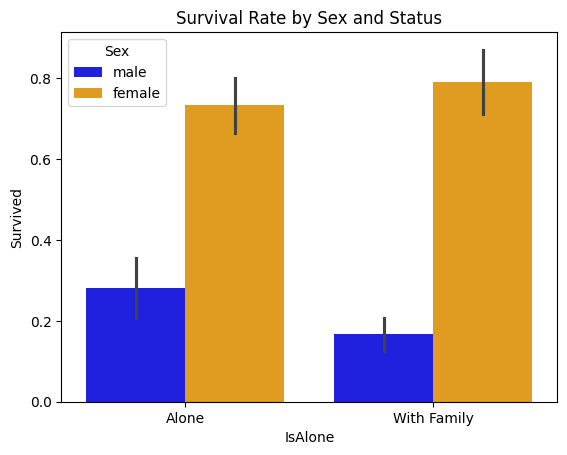

Sex     IsAlone
female  0          0.732919
        1          0.790000
male    0          0.281879
        1          0.167763
Name: Survived, dtype: float64

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='IsAlone',
    y='Survived',
    hue='Sex',
    data=df,
    palette={'female': 'orange', 'male': 'blue'}
)

plt.xticks([0,1], ['Alone', 'With Family'])
plt.title('Survival Rate by Sex and Status')
plt.show()

df.groupby(['Sex','IsAlone'])['Survived'].mean()

- 女性かつ家族のグループは生存率が高い

# 家族構成の大きさも考慮した生存率

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [15]:
def family_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilyGroup'] = df['FamilySize'].apply(family_category)

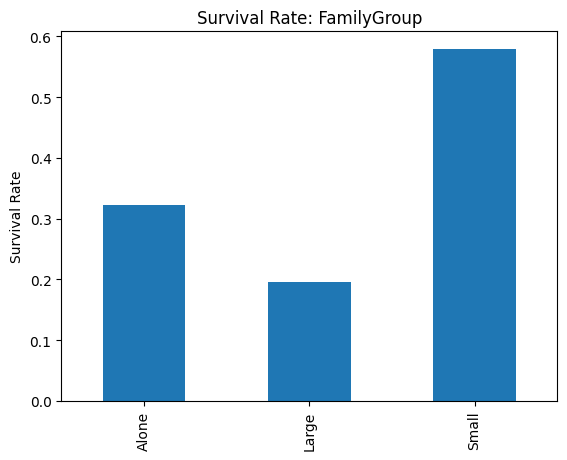

FamilyGroup
Alone    0.321782
Large    0.196078
Small    0.579151
Name: Survived, dtype: float64

In [16]:
#グラフ
survival_rate = df.groupby('FamilyGroup')['Survived'].mean()

survival_rate.index = ['Alone','Large','Small']

survival_rate.plot(kind='bar')
plt.title('Survival Rate: FamilyGroup')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('FamilyGroup')['Survived'].mean()

- 家族構成のサイズでは差が生まれた。
- 救助の際の動きやすさも関係？

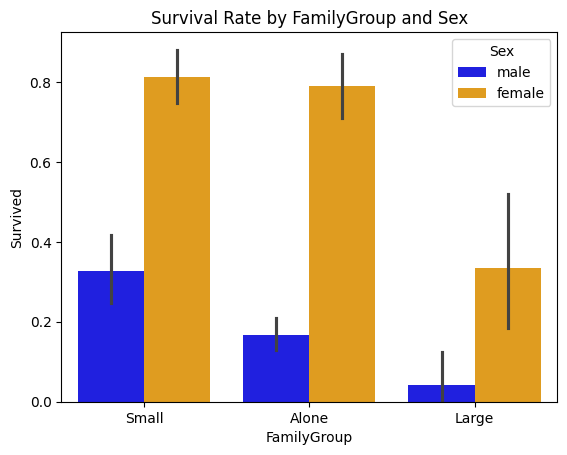

Sex     FamilyGroup
female  Alone          0.790000
        Large          0.333333
        Small          0.813433
male    Alone          0.167763
        Large          0.041667
        Small          0.328000
Name: Survived, dtype: float64

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='FamilyGroup',
    y='Survived',
    hue='Sex',
    data=df,
    palette={'female': 'orange', 'male': 'blue'}
)
plt.title('Survival Rate by FamilyGroup and Sex')
plt.show()

df.groupby(['Sex','FamilyGroup'])['Survived'].mean()

- 女性かつ独身もしくは女性かつSmallのグループはどちらも生存率が高い
- 男性の場合Small,Alone,Largeの順番で低く、生存率は女性の半分以下であった

# 結果
すべての乗客を対象に男女別の生存率を分析した結果、女性の生存率は男性の約3.9倍と大きな差が確認された。

さらに家族構成との関係を分析したところ、2〜4人の小規模家族（Small）における生存率が約80%と最も高いことがわかった。

また男性においてもSmallの生存率が最も高い傾向が見られたが、いずれの家族構成においても女性の生存率が一貫して高い結果となった。

これらの結果から、性別および家族構成が生存率に大きく影響していることが示唆される。

# ＊チケットクラスごとの生存率

In [18]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.655914
2    0.479769
3    0.239437
Name: Survived, dtype: float64

1. 62.9%
2. 47.2%
3. 24.2%

救助の優先度も生存率に影響することが考えられたためチケットクラスごとに生存率を出した結果差が生まれていたため改善点として追加で分析してもよい？